# VaR と期待ショートフォール（Hull 11e Ch.22）

`johnhull/volumes` シリーズ第8冊。市場リスクを1つの数値に集約する：

- **VaR** — 「信頼水準 α で N 日間に超えない損失」／ **ES** — 超えたときの条件付き期待損失
- **分散共分散法** — Hull の Microsoft/AT&T 例を完全再現
- **ヒストリカル・シミュレーション** — 太い裾と正規仮定の乖離
- **オプションの VaR** — デルタ近似 vs デルタ-ガンマ vs 完全再評価（第3冊・第6冊の道具で）

> VaR は劣加法性を満たさない（→ Basel FRTB は ES 97.5% へ移行）— 反例も作ります

In [1]:
%matplotlib widget

In [2]:
# --- imports & 共通設定 ---
import math

import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from scipy.stats import norm, t as t_dist

from hullkit import bsm, mc, nbplot, risk

plt = nbplot.setup()  # japanize_matplotlib + plt.ioff()

## 1. 定義（Ch.22）

$$\Pr(L > \mathrm{VaR}_\alpha) = 1 - \alpha, \qquad
\mathrm{ES}_\alpha = E[L \mid L > \mathrm{VaR}_\alpha]$$

- VaR は分位点（「どこから先がテールか」）、ES はテールの**深さの平均**
- iid 正規なら $\mathrm{VaR}_{N日} = \sqrt{N}\,\mathrm{VaR}_{1日}$（ボラ・クラスタリングがあると過小評価 — 第5冊）

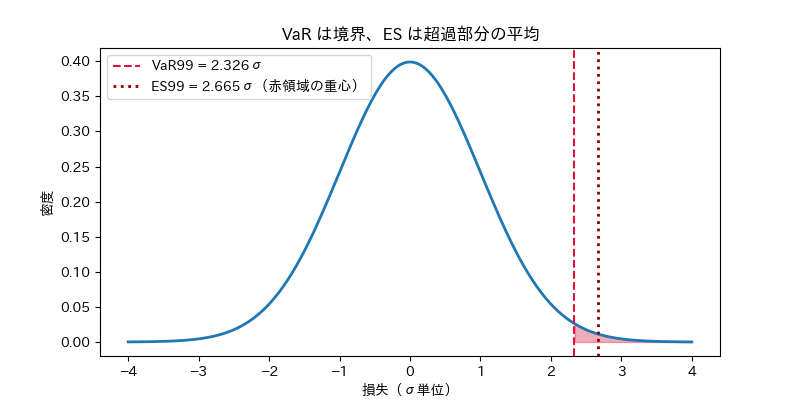

In [3]:
# --- 損失分布上の VaR と ES ---
sigma_demo = 1.0
z99 = norm.ppf(0.99)
es99 = norm.pdf(z99) / 0.01
x_l = np.linspace(-4.0, 4.0, 400)

fig1, ax1 = plt.subplots(figsize=(8, 4))
fig1.canvas.header_visible = False
ax1.plot(x_l, norm.pdf(x_l), lw=2)
ax1.fill_between(x_l, 0.0, norm.pdf(x_l), where=x_l >= z99, alpha=0.35, color="crimson")
ax1.axvline(z99, color="crimson", ls="--", lw=1.5, label=f"VaR99 = {z99:.3f}σ")
ax1.axvline(es99, color="darkred", ls=":", lw=2, label=f"ES99 = {es99:.3f}σ（赤領域の重心）")
ax1.set_xlabel("損失（σ単位）")
ax1.set_ylabel("密度")
ax1.set_title("VaR は境界、ES は超過部分の平均")
ax1.legend()
display(fig1.canvas)

## 2. VaR は「コヒーレント」でない（Ch.22）

コヒーレントなリスク指標の4公理のうち、VaR は**劣加法性**
$\rho(A+B) \le \rho(A) + \rho(B)$ を満たさないことがある —
「分散化でリスク指標が増える」逆転が起こり得ます。ES は4公理すべてを満たします。

この理由で Basel（FRTB）は市場リスクの基準を **VaR 99% → ES 97.5%** に変更しました。

In [4]:
# --- 劣加法性の反例: 独立な「0.8%で-10、それ以外0」の損失2つ ---
p_bad, loss_bad = 0.008, 10.0
# 単独: P(L >= 10) = 0.8% < 1% → VaR99 = 0
var_single = 0.0 if p_bad < 0.01 else loss_bad
# 合算: P(L >= 10) = 1 - (1-p)^2 ≈ 1.594% > 1% → VaR99 = 10
p_any = 1.0 - (1.0 - p_bad) ** 2
var_combined = loss_bad if p_any > 0.01 else 0.0
print(f"単独ポジションの VaR99 = {var_single}（P(大損) = {p_bad:.2%} < 1%）")
print(f"2つ合わせた VaR99 = {var_combined}（P(どちらか大損) = {p_any:.3%} > 1%）")
print(f"劣加法性: VaR(A+B) = {var_combined} > VaR(A)+VaR(B) = {2 * var_single} → 破れ")

# ES は破れない: 単独 ES99 = E[L|L>VaR]= 10×0.008/0.01 = 8 → 2つで16 ≥ 合算ES
es_single = loss_bad * p_bad / 0.01
print(f"参考: 単独 ES99 = {es_single}（テールを最初から見ている）")

単独ポジションの VaR99 = 0.0（P(大損) = 0.80% < 1%）
2つ合わせた VaR99 = 10.0（P(どちらか大損) = 1.594% > 1%）
劣加法性: VaR(A+B) = 10.0 > VaR(A)+VaR(B) = 0.0 → 破れ
参考: 単独 ES99 = 8.0（テールを最初から見ている）


## 3. 分散共分散法（モデル構築法）（Ch.22）

リターンを多変量正規と仮定すると解析解：

$$\sigma_P = \sqrt{\boldsymbol{\alpha}^\top C \boldsymbol{\alpha}}, \qquad
\mathrm{VaR} = z_\alpha\,\sigma_P\sqrt{N}, \qquad
\mathrm{ES} = \sigma_P\sqrt{N}\,\frac{\phi(z_\alpha)}{1-\alpha}$$

（$\boldsymbol{\alpha}$: ドル投資額ベクトル、$C_{ij} = \rho_{ij}\sigma_i\sigma_j$ 日次）

In [5]:
# --- Hull の例: Microsoft $10M（σ=2%/日）+ AT&T $5M（σ=1%/日）、ρ=0.3 ---
v_ms = risk.normal_var(200_000.0, alpha=0.99, horizon=10.0)
v_att = risk.normal_var(50_000.0, alpha=0.99, horizon=10.0)
sig_p = risk.portfolio_sigma([10e6, 5e6], [0.02, 0.01], [[1.0, 0.3], [0.3, 1.0]])
v_port = risk.normal_var(sig_p, alpha=0.99, horizon=10.0)
display(pd.DataFrame([
    {"ポジション": "Microsoft $10M", "σ（日次$）": 200_000, "10日99%VaR": round(v_ms)},
    {"ポジション": "AT&T $5M", "σ（日次$）": 50_000, "10日99%VaR": round(v_att)},
    {"ポジション": "ポートフォリオ（ρ=0.3）", "σ（日次$）": round(sig_p), "10日99%VaR": round(v_port)},
]))
print(f"分散化メリット = {v_ms + v_att - v_port:,.0f}（Hull: 約219,000）")

,ポジション,σ（日次$）,10日99%VaR
0,Microsoft $10M,200000,1471312
1,AT&T $5M,50000,367828
2,ポートフォリオ（ρ=0.3）,220227,1620114


分散化メリット = 219,026（Hull: 約219,000）


In [6]:
es_port = risk.normal_es(sig_p, alpha=0.99, horizon=10.0)
print(f"ポートフォリオの 10日 99% ES = {es_port:,.0f}")
print(f"ES / VaR = {es_port / v_port:.4f}（正規なら α=99% で常に {norm.pdf(norm.ppf(0.99)) / 0.01 / norm.ppf(0.99):.4f}）")

ポートフォリオの 10日 99% ES = 1,856,107
ES / VaR = 1.1457（正規なら α=99% で常に 1.1457）


FloatSlider(value=0.3, description='ρ', max=1.0, min=-1.0, step=0.05)

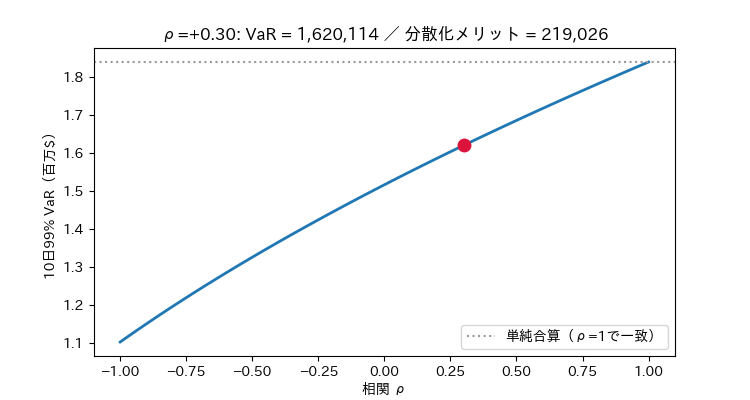

In [7]:
# --- 相関と分散化メリット（インタラクティブ） ---
fig2, ax2 = plt.subplots(figsize=(7.5, 4))
fig2.canvas.header_visible = False
rho_sl = widgets.FloatSlider(value=0.3, min=-1.0, max=1.0, step=0.05, description="ρ")


def _upd_rho(change=None):
    ax2.clear()
    rhos = np.linspace(-1.0, 1.0, 81)
    vars_p = [risk.normal_var(
        risk.portfolio_sigma([10e6, 5e6], [0.02, 0.01], [[1.0, r_], [r_, 1.0]]),
        alpha=0.99, horizon=10.0) for r_ in rhos]
    ax2.plot(rhos, np.array(vars_p) / 1e6, lw=2)
    ax2.axhline((v_ms + v_att) / 1e6, color="0.6", ls=":", label="単純合算（ρ=1で一致）")
    r_now = rho_sl.value
    v_now = risk.normal_var(
        risk.portfolio_sigma([10e6, 5e6], [0.02, 0.01], [[1.0, r_now], [r_now, 1.0]]),
        alpha=0.99, horizon=10.0)
    ax2.plot(r_now, v_now / 1e6, "o", ms=9, color="crimson")
    ax2.set_xlabel("相関 ρ")
    ax2.set_ylabel("10日99% VaR（百万$）")
    ax2.set_title(f"ρ={r_now:+.2f}: VaR = {v_now:,.0f} ／ 分散化メリット = {v_ms + v_att - v_now:,.0f}")
    ax2.legend()
    fig2.canvas.draw_idle()


rho_sl.observe(_upd_rho, "value")
_upd_rho()
display(rho_sl, fig2.canvas)

### √N スケーリングの注意

$\sqrt{N}$ 規則は「日次リターンが iid」前提。第5冊で見たとおり実際は
**ボラティリティ・クラスタリング**があり、高ボラ局面では持続性（GARCH の α+β）
のぶん過小評価になります。規制（FRTB）は重なり合う10日リターンや
ストレス期間カリブレーションでこれに対処しています。

### ここまでの前提

分散共分散法は **(a) 線形ポジション (b) 正規リターン** の2つを仮定しています。
次節でそれぞれを外します：(b) → ヒストリカル法、(a) → デルタ-ガンマ近似。